In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("IPL_ball_by_ball_updated.csv")
df["total_runs"] = df["runs_off_bat"] + df["extras"]
print("Dataset loaded successfully")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully
Shape: (243815, 23)


,match_id,season,start_date,venue,innings,ball,batting_team,bowling_team,striker,non_striker,bowler,runs_off_bat,extras,wides,noballs,byes,legbyes,penalty,wicket_type,player_dismissed,other_wicket_type,other_player_dismissed,total_runs
0,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.1,Kolkata Knight Riders,Royal Challengers Bangalore,SC Ganguly,BB McCullum,P Kumar,0,1,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1
1,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.2,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,P Kumar,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.3,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,P Kumar,0,1,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
3,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.4,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,P Kumar,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.5,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,P Kumar,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


In [2]:
team_runs = df.groupby("batting_team")["runs_off_bat"].sum().nlargest(10).sort_values()
team_runs

batting_team
Deccan Chargers                10885
Delhi Capitals                 11764
Delhi Daredevils               23022
Sunrisers Hyderabad            24735
Kings XI Punjab                28541
Rajasthan Royals               30541
Chennai Super Kings            34334
Kolkata Knight Riders          34668
Royal Challengers Bangalore    35810
Mumbai Indians                 37523
Name: runs_off_bat, dtype: int64

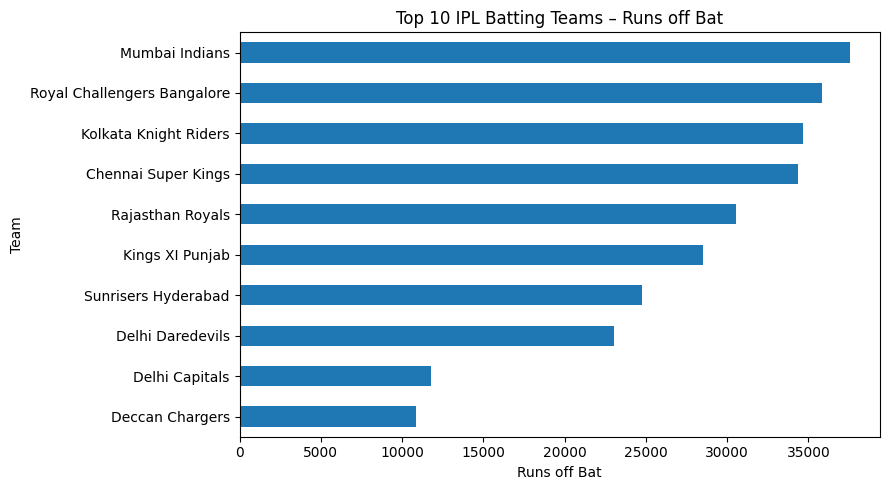

In [3]:
plt.figure(figsize=(9,5))
team_runs.plot(kind="barh")
plt.title("Top 10 IPL Batting Teams – Runs off Bat")
plt.xlabel("Runs off Bat")
plt.ylabel("Team")
plt.tight_layout()
plt.show()

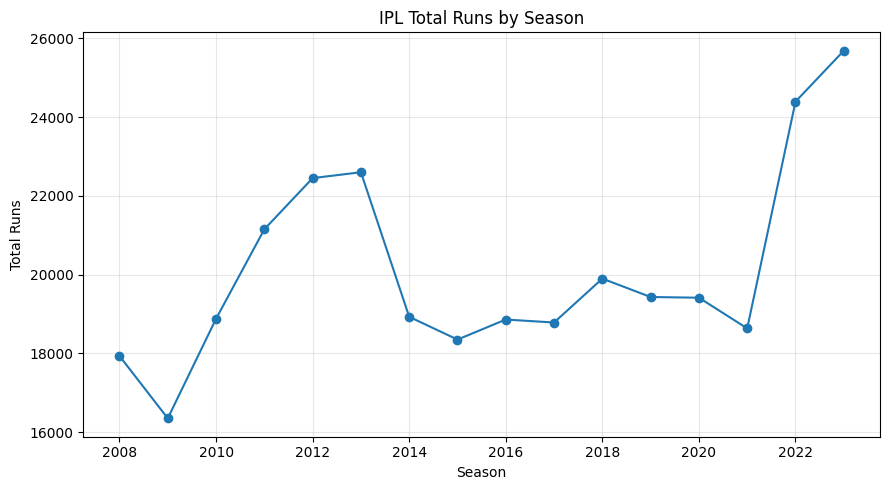

In [4]:
season_runs = df.groupby("season")["total_runs"].sum()
plt.figure(figsize=(9,5))
plt.plot(season_runs.index, season_runs.values, marker="o")
plt.title("IPL Total Runs by Season")
plt.xlabel("Season")
plt.ylabel("Total Runs")
plt.grid(True, alpha=.3)
plt.tight_layout()
plt.show()

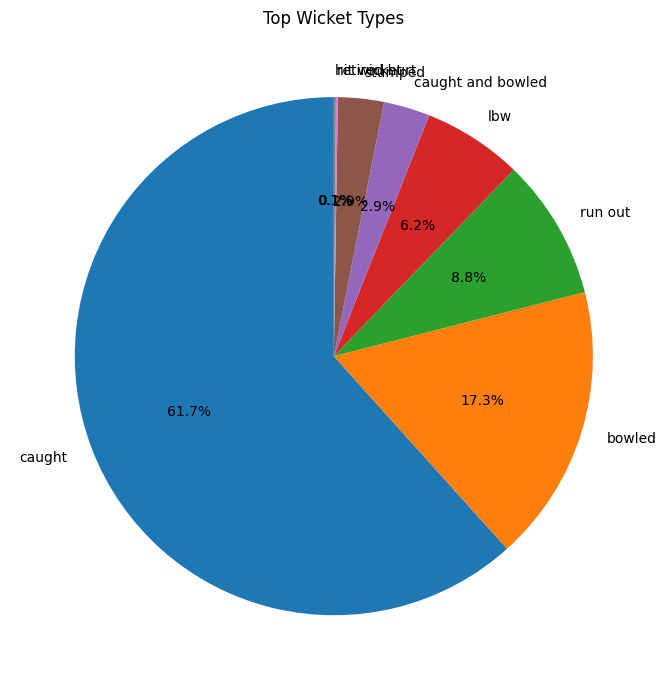

In [5]:
wickets = df.loc[df["wicket_type"].notna(),"wicket_type"].value_counts().head(8)
plt.figure(figsize=(7,7))
plt.pie(wickets.values, labels=wickets.index, autopct="%1.1f%%", startangle=90)
plt.title("Top Wicket Types")
plt.tight_layout()
plt.show()

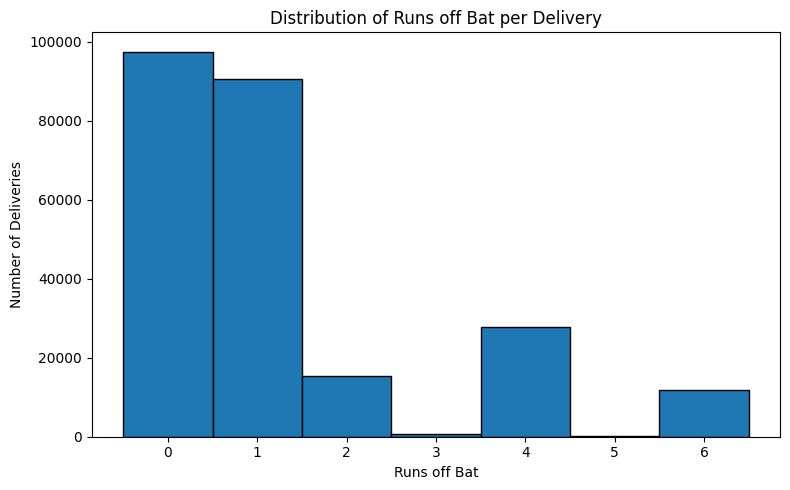

In [6]:
plt.figure(figsize=(8,5))
plt.hist(df["runs_off_bat"], bins=range(0,8), edgecolor="black", align="left")
plt.title("Distribution of Runs off Bat per Delivery")
plt.xlabel("Runs off Bat")
plt.ylabel("Number of Deliveries")
plt.xticks(range(0,7))
plt.tight_layout()
plt.show()

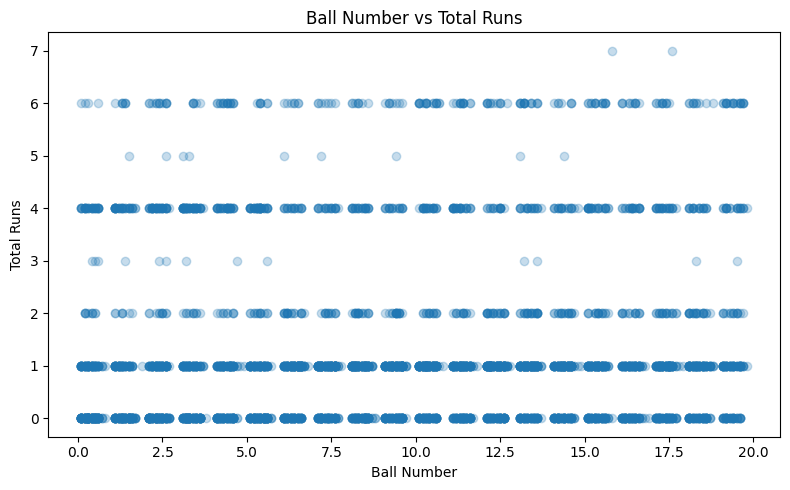

In [7]:
sample = df.sample(5000, random_state=42)
plt.figure(figsize=(8,5))
plt.scatter(sample["ball"], sample["total_runs"], alpha=.25)
plt.title("Ball Number vs Total Runs")
plt.xlabel("Ball Number")
plt.ylabel("Total Runs")
plt.tight_layout()
plt.show()